# Wstęp do Sztucznej Inteligencji
## Ewolucyjne podejście do optymalizacji klasyfikatora opartego na zestawie reguł rozmytych

Celem laboratorium jest implementacja klasyfikatora opartego na regułach rozmytych. Postać reguł rozmytych może być optymalizowana za pomocą algorytmu ewolucyjnego.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

Zaczniemy od prostego problemu klasyfikacyjnego irysów. Dane te opisują 150 przykładów kwiatów, każdy należący do jednego z trzech gatunków. Mamy zatem do czynienia z problemem klasyfikacyjnym z trzema klasami.

Każdy przykład opisany jest czterema atrybutami (cechami). Na ich podstawie nasz klasyfikator ma podejmować decyzję, do której klasy przypisać dany przykład. 

Proces uczenia takiego modelu to przykład uczenia z nauczycielem (ang. supervised learning).


In [2]:
from sklearn.preprocessing import LabelEncoder

data_path = 'iris.csv'
data = pd.read_csv(data_path, header=None, delimiter=r"\s+")
data.columns = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']
print(data.head())

# encode as np matrix
X = features_matrix = data.iloc[:, 0:4].to_numpy()
print(X.shape)
Y = data['Species'].to_numpy()
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)
print(Y)



   SepalLength  SepalWidth  PetalLength  PetalWidth      Species
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa
(150, 4)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Po wczytaniu danych, warto się im przyjrzeć i ocenić trudność problemu.

Które atrybuty wydają się szczególnie przydatne w tym problemie? Zwróć uwagę, że przy takiej wizualizacji danych nie widzimy dokładnie jak dobrze te dane są odseparowane w oryginalnej przestrzeni (w tym przypadku 4D).

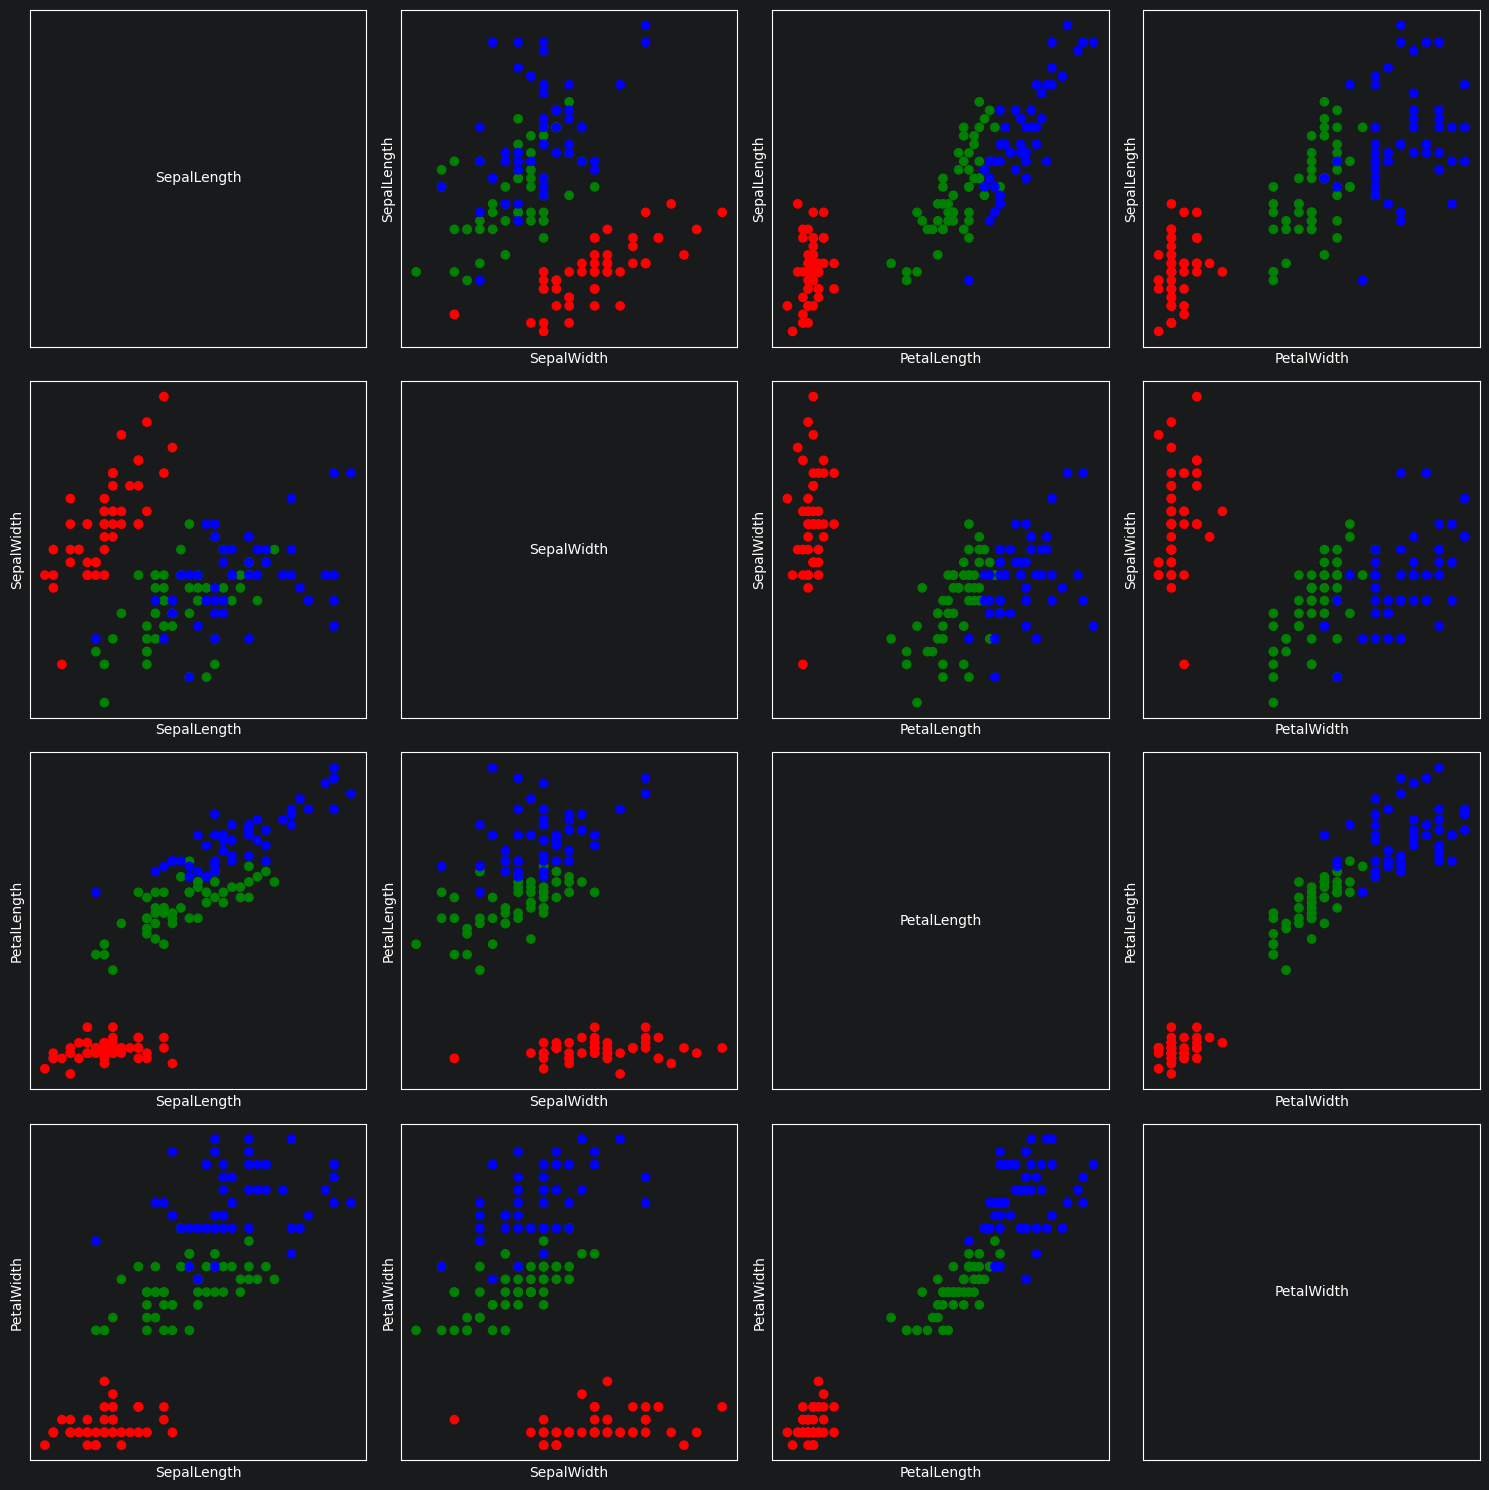

In [3]:
colors = ['red', 'green', 'blue']
data['Species'] = Y
# Rysowanie wykresów dla każdej pary cech
fig, axs = plt.subplots(4, 4, figsize=(15, 15))  # Ustawienie siatki wykresów
for i in range(4):
	for j in range(4):
		if i != j:
			axs[i, j].scatter(data.iloc[:, j], data.iloc[:, i], c=data['Species'].map(lambda x: colors[x]))
			axs[i, j].set_xlabel(data.columns[j])
			axs[i, j].set_ylabel(data.columns[i])
		else:
			axs[i, j].text(0.5, 0.5, data.columns[i], horizontalalignment='center', verticalalignment='center')
			axs[i, j].set_xlabel('')
			axs[i, j].set_ylabel('')
		axs[i, j].set_xticks([])
		axs[i, j].set_yticks([])

plt.tight_layout()
plt.show()

Dane dzielimy na dane trenujące i testowe. Klasyfikator powinien być przetestowany na danych, z którymi nie miał styczności w czasie procesu uczenia.

In [4]:
test_perc = 0.3
indxs = np.random.permutation(X.shape[0])
ii = int(test_perc * X.shape[0])
Xtest = X[indxs[:ii]]
Ytest = Y[indxs[:ii]]
X = X[indxs[ii:]]
Y = Y[indxs[ii:]]
print(X.shape, Xtest.shape)

(105, 4) (45, 4)


Do zdefiniowania funkcji przynależności potrzebne będą zakresy wartości zmiennych.

In [5]:
mins = X.min(axis=0)
maxs = X.max(axis=0)
print(mins)
print(maxs)

[4.3 2.  1.  0.1]
[7.9 4.4 6.9 2.5]


Nasz przykładowy klasyfikator rozmyty będzie korzystał z trójkątnych funkcji przynależności.

In [6]:
def trfun(x, a, b, c):
	return 0 if (x < a or x > c) else ((x - a) / (b - a) if (x >= a and x <= b) else (c - x) / (c - b))

Klasyfikator rozmyty podejmuje decyzję na podstawie zbioru reguł rozmytych w postaci:

JEŚLI x1 jest MAŁE i x2 jest ŚREDNIE i x4 jest DUŻE wtedy KLASA_1

Zwróć uwagę, że w powyższym przykładzie nie jest wykorzystane x3.

Obiekt poniższej klasy FuzzyClassifier przechowuje dla każdego wymiaru (x1 do x4 w przypadku irysów) zadaną liczbę wartości lingwistycznych reprezentowanych przez trójkątne funkcje prznależności definiowane przez trzy parametry. Dla każdego wymiaru może to być różna liczba (parametr fnums).

Reguły rozmyte zakodowane są w polu rules. Każda reguła to lista, której kolejne wartości wskazują, do której funkcji przynależności odnosi się ta reguła w danym wymiarze, a ostatni element to indeks klasy z wniosku reguły. Jeśli występuje wartość -1, to ten atrybut nie jest brany pod uwagę przez daną regułę.

Przykład:

[-1, -1, 0, 2, 2]

Reguła ta odnosi się do x3 (pierwsza funckcja przynależności) oraz x4 (trzecia funkcja przynależności). We wniosku wskazuje klasę o indeksie 2 (trzecią).

Podczas klasyfikacji sprawdzane są wartości odpowiednich funkcji przynależności dla konkretnych wartości x1 do x4. Stopień spełnialności części warunkowej danej reguły określany jest za pomocą odpowiedniej t-normy (minimum w tym przykładzie). Jeśli więcej niż jedna reguła ma we wniosku daną klasę, wartości stopni spełnialności warunków tych reguł agregowane są za pomocą odpowiedniej s-normy (maksimum w tym przykładzie). Ostatecznie wybierana jest klasa, na którą wskazuje maksymalna wartość.

In [7]:
class FuzzyClassifier:
	def __init__(self, nclass, dim, fnums, mins, maxs):
		self.nclass = nclass  #number of classes
		self.dim = dim  #number of input features
		self.fnums = fnums  #list: number of linguistic values for each feature
		self.mins = mins  #minimum values of features
		self.maxs = maxs  #maximum values of features
		self.funs = None  #parametry funkcji przynależności (tu: trójkątnej)
		self.rules = None  #reguły
		self.tnorm_condition = None  #t-norma używana do oceny części warunkowej reguły
		self.snorm_aggregation = None  #s-norma używana do agregacji

	def init_triangular_funs(self):
		"""
        Dla każdego wymiaru generuje zadaną liczbę równomiernie rozłożonych trójkątnych funkcji przynależności
        """
		self.funs = []
		for i in range(self.dim):
			step = (self.maxs[i] - self.mins[i]) / (self.fnums[i] - 1)
			tmp = []
			for j in range(self.fnums[i]):
				center = self.mins[i] + j * step
				tmp.append((center - step, center, center + step))
			self.funs.append(tmp)

	def gen_random_rules(self, n):
		"""
        Generuje zadaną liczbę losowych reguł
        """
		return [[np.random.randint(-1, num) for num in self.fnums] + [np.random.randint(0, nclass)] for i in range(n)]

	def classify(self, x):
		"""
        Klasyfikuje pojedynczy przykład x
        """
		votes = [[] for i in range(self.nclass)]
		for r in self.rules:
			conditions = []
			for i, findx in enumerate(r[:-1]):
				if findx == -1:
					continue
				a, b, c = self.funs[i][findx]
				conditions.append(trfun(x[i], a, b, c))
			condition_sat_level = self.tnorm_condition(conditions) if len(conditions) > 0 else 0
			votes[r[-1]].append(condition_sat_level)
		votes = [self.snorm_aggregation(v) if len(v) > 0 else 0 for v in votes]
		return np.argmax(votes)

	def classify_all(self, X):
		"""
        Klasyfikuje wszystkie przykłady - wiersze macierzy X
        """
		return np.array([self.classify(x) for x in X])

	def test(self, X, Y):
		"""
        Klasyfikuje przykłady z X i porównuje z prawidłowymi etykietami klas z Y

        Zwraca accuracy - odsetek poprawnych klasyfikacji
        """
		return (Y == self.classify_all(X)).sum() / X.shape[0]


Ustawienia dla problemu irysów:

In [8]:
nclass = 3  #liczba klas
dim = 4  #liczba atrybutów
fnums = [3, 3, 3, 3]  #liczba funcji przynależności (wartości lingwistycznych) dla każdego atrybutu

Tworzymy obiekt FuzzyClassifier i wizualizujemy funkcje przynależności.

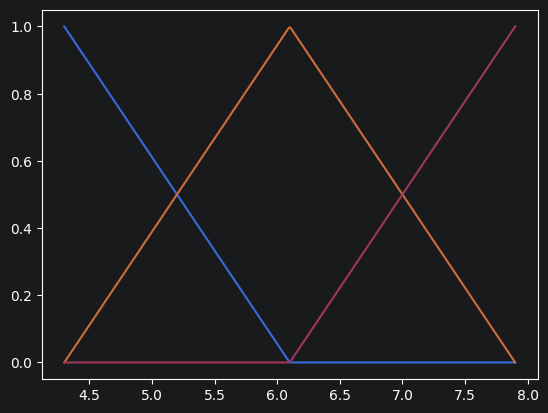

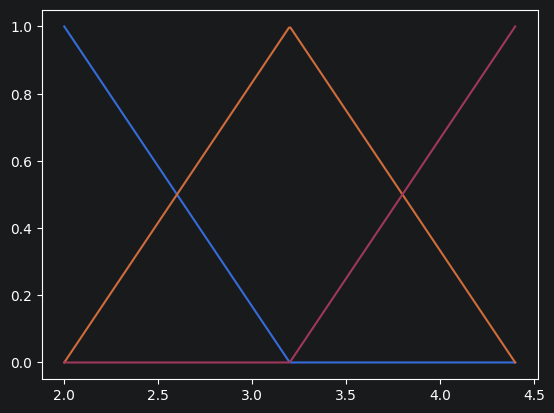

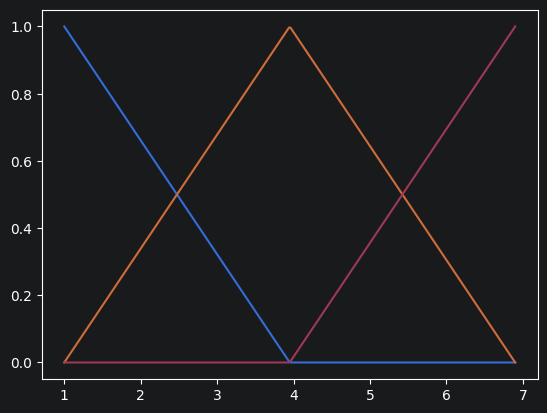

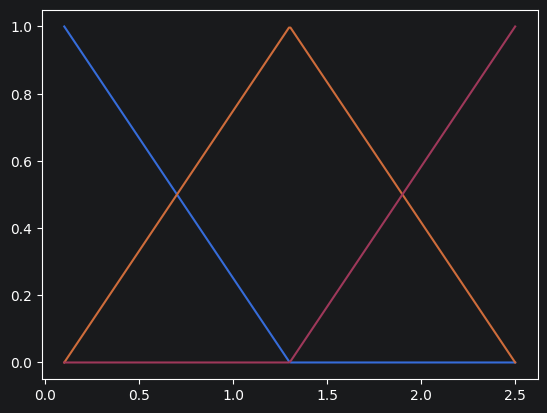

In [9]:
fc = FuzzyClassifier(nclass, dim, fnums, mins, maxs)
fc.init_triangular_funs()
for i, f in enumerate(fc.funs):
	xx = np.linspace(mins[i], maxs[i], 300)
	plt.figure()
	for ff in f:
		a, b, c = ff
		mfun = np.vectorize(lambda x: trfun(x, a, b, c), otypes=[float])
		yy = mfun(xx)
		plt.plot(xx, yy)
plt.show()


Generujemy przykładowe reguły

In [12]:
r = fc.gen_random_rules(3)
print(r)

# Przy ustawieniach fnums = [5, 5, 5, 5] następujące reguły dają całkiem nieźle działajacy klasyfikator
# fc.rules = [[-1, -1, -1, 4, 2], [-1, -1, -1, 3, 2], [-1, -1, -1, 2, 1], [-1, -1, 1, -1, 0]]

[[-1, 1, 0, 0, 0], [-1, 0, 0, 1, 0], [1, -1, 0, -1, 0]]


Ustawiamy t-normę i s-normę

In [13]:
fc.tnorm_condition = lambda x: min(x)
fc.snorm_aggregation = lambda x: max(x)

Test klasyfikatora

In [14]:
fc.rules = r
acc = fc.test(X, Y)
print(acc)
Z = fc.classify_all(X)
print(Z)

0.37142857142857144
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


Mutacja będzie polegać na zmianie aktualnej wartości na losową, dozwoloną na danej pozycji (z pewnym prawdopodobieństwem).

In [15]:
def mutate(rule_set, prob_mut):
	"""
    Mutacja poprzez zmianę na losową wartość dopuszczalną na danej pozycji.
    Klasa z wniosku reguły również może się zmienić.
    """
	for r in rule_set:
		for i in range(fc.dim):
			if np.random.rand() < prob_mut:
				r[i] = np.random.randint(-1, fc.fnums[i])
		if np.random.rand() < prob_mut:
			r[-1] = np.random.randint(0, fc.nclass)

Generujemy losową początkową populację.

Każdy osobnik koduje cały zestaw reguł rozmytych.

Wszytkie osobniki korzystać będą z tego samego zestawu funkcji przynależności.

In [16]:
nrules = 5
pop_size = 10
pop = [fc.gen_random_rules(nrules) for i in range(pop_size)]
print(pop)

[[[-1, -1, 0, -1, 0], [0, -1, -1, 2, 1], [1, -1, 0, 0, 2], [-1, 0, 1, 2, 1], [2, 1, 2, 2, 1]], [[0, 0, -1, -1, 2], [2, -1, -1, 1, 1], [0, 2, 2, 1, 2], [-1, 1, 0, 2, 1], [2, 0, -1, 2, 0]], [[1, -1, 1, -1, 0], [2, 1, -1, 1, 1], [2, 1, -1, 0, 1], [1, 0, -1, 0, 0], [-1, -1, 0, -1, 1]], [[0, 0, 1, 2, 2], [2, -1, -1, 0, 2], [-1, 2, 0, 0, 1], [0, -1, 2, 1, 2], [0, 1, 2, 1, 2]], [[2, -1, 1, 1, 0], [0, -1, 2, -1, 1], [0, 1, -1, 2, 1], [-1, -1, -1, 2, 2], [1, -1, 0, -1, 1]], [[2, 2, 0, -1, 0], [1, 0, 2, 0, 0], [1, -1, 0, -1, 2], [-1, 0, -1, 1, 1], [-1, -1, 0, -1, 1]], [[0, 2, 0, 2, 0], [1, 1, 1, -1, 0], [0, 1, -1, 1, 2], [2, 1, 0, -1, 2], [-1, 1, -1, 0, 1]], [[0, -1, 0, -1, 1], [0, -1, 0, 2, 1], [1, 2, 0, 2, 2], [2, 1, 1, -1, 2], [0, -1, -1, 2, 2]], [[0, 0, 1, -1, 1], [0, 2, 1, -1, 1], [1, 0, 1, 0, 0], [2, 1, 2, 2, 0], [2, -1, -1, 2, 1]], [[0, 2, -1, -1, 2], [-1, 0, -1, 2, 2], [1, -1, -1, 0, 0], [0, -1, 2, 0, 1], [-1, -1, 0, 0, 1]]]


Ewaluacja osobników i zapamiętanie najlepszego.

Funkcją przystosowania jest odsetek poprawnych klasyfikacji na zbiorze trenującym.

In [17]:
evals = []
for rule_set in pop:
	fc.rules = rule_set
	evals.append(fc.test(X, Y))
print(evals)

srt = sorted(zip(evals, pop))[::-1]
best_rs = copy.deepcopy(srt[0][1])
best_eval = srt[0][0]
print('best ', best_eval)
print(best_rs)

[np.float64(0.5238095238095238), np.float64(0.4095238095238095), np.float64(0.0), np.float64(0.20952380952380953), np.float64(0.44761904761904764), np.float64(0.26666666666666666), np.float64(0.009523809523809525), np.float64(0.3333333333333333), np.float64(0.2761904761904762), np.float64(0.2571428571428571)]
best  0.5238095238095238
[[-1, -1, 0, -1, 0], [0, -1, -1, 2, 1], [1, -1, 0, 0, 2], [-1, 0, 1, 2, 1], [2, 1, 2, 2, 1]]


Przykładowy algorytm ewolucyjny jest bardzo prosty. 

Jego jedyny operator to mutacja.

Każdy z osobników z aktualnej populacji jest kopiowany a następnie mutowany.

Stara i nowa (zmutowana) populacja są łączone.

Pozostawiamy pop_size najlepszych osobników (nacisk selekcyjny).

Przetestujmy jego działanie.

In [18]:
iters = 100
prob_mut = 0.1

for i in range(iters):
	# kopiowanie każdego osobnika
	pop2 = [copy.deepcopy(rs) for rs in pop]
	# mutacja
	for rule_set in pop2:
		mutate(rule_set, prob_mut)
	# ocena nowych rozwiązań
	evals2 = []
	for rule_set in pop2:
		fc.rules = rule_set
		evals2.append(fc.test(X, Y))
	# łączenie obu populacji
	pop = pop + pop2
	evals = evals + evals2
	# pozostawienie stałej liczby najlepszych osobników
	srt = sorted(zip(evals, pop))[::-1]
	pop = [s[1] for s in srt][:pop_size]
	evals = [s[0] for s in srt][:pop_size]
	# zapamiętanie najlepszego rozwiązania
	if evals[0] > best_eval:
		print('better found', evals[0], 'in', i + 1)
		best_eval = evals[0]
		best_rs = copy.deepcopy(pop[0])
print('end')


better found 0.6095238095238096 in 3
better found 0.780952380952381 in 4
better found 0.7904761904761904 in 9
better found 0.8666666666666667 in 10
better found 0.8952380952380953 in 24
better found 0.9047619047619048 in 31
better found 0.9142857142857143 in 44
better found 0.9238095238095239 in 86
end


Spradzamy odpowiedzi najlepszego osobnika na zbiorze trenującym:

In [19]:
print(best_eval)
print(best_rs)
fc.rules = best_rs
z = fc.classify_all(X)
print(z)
print(Y)
print(fc.test(X, Y))

0.9238095238095239
[[2, -1, 2, 1, 2], [1, 1, 2, 1, 1], [0, 0, -1, 2, 1], [-1, -1, -1, 2, 2], [2, -1, 1, 2, 1]]
[0 2 2 0 2 2 2 0 1 0 1 0 1 2 0 0 2 0 1 1 0 0 2 1 0 2 0 1 1 0 0 1 2 0 1 1 0
 1 0 0 0 2 0 1 1 1 0 1 1 1 0 1 0 0 0 1 2 2 2 2 2 0 1 0 2 0 2 2 0 1 1 2 2 2
 2 1 2 1 2 0 2 2 1 2 0 0 2 0 2 0 1 2 0 0 1 0 0 0 0 0 0 2 2 2 0]
[1 2 2 0 2 1 2 1 1 0 1 0 1 2 0 0 2 0 1 2 0 0 2 1 0 2 0 1 1 0 0 1 2 1 1 2 0
 1 0 0 0 2 0 1 1 1 0 1 1 1 1 1 0 0 0 1 1 2 2 2 2 0 1 0 2 0 2 2 0 1 1 2 2 2
 2 1 2 1 2 0 2 2 1 2 0 0 2 0 2 0 1 2 0 0 1 0 0 0 0 0 0 2 2 2 0]
0.9238095238095239


...oraz testowym.

In [20]:
# testing
ans = fc.classify_all(Xtest)
print(ans)
print(Ytest)
print(fc.test(Xtest, Ytest))

[2 1 0 1 1 2 0 1 1 0 0 0 2 0 2 2 2 1 0 1 2 0 0 1 2 1 2 1 0 1 0 0 0 2 2 0 1
 0 1 1 1 0 2 1 0]
[2 1 0 1 2 2 0 1 1 0 0 1 2 1 2 2 2 2 0 1 2 0 0 1 2 2 1 1 0 1 1 0 0 2 2 1 1
 0 2 1 1 1 2 2 1]
0.7333333333333333


Wykonaj przykładowe obliczenia dla różnych ustawień (liczba funckji przynależności, liczba reguł, wielkość populacji itd.)

### Zadanie (10 punktów)

In [21]:
nr_indeksu = 155197

In [22]:
print(r"""
Zaimplementuj mój algorytm ewolucyjny do optymalizacji klasyfikatora rozmytego. 

Przetestuj go na trudniejszym problemie klasyfikacyjnym diagnozy cukrzycy (baza pima - ostatnia kolumna zawiera etykietę klasy).

Ile minimalnie reguł jest potrzebnych?

Wnioski zaprezentuj na podstawie średniej z co najmniej 10 uruchomień.

W algorytmie dodaj możliwość ewolucji parametrów użytych funkcji przynależności 
(a więc nie są one wspólne dla wszytkich rozwiązań lecz podlegają optymalizacji).

Porównaj działanie swojego algorytmu z przykładowym algorytmem z zajęć.

Algorytm powinien mieć następujące funkcjonalności 
(zastosuj operator krzyżowania nawet jeśli nie występuje on w oryginalnym opisie algorytmu):
""")

algorytm = ['algorytm genetyczny', 'strategia ewolucyjna u+s', 'strategia ewolucyjna u,s', 'programowanie ewolucyjne']
selekcja = ['koło ruletki', 'turniejowa', 'rankingowa']
xover = ['jednopunktowe', 'dwupunktowe', 'jednostajne', 'uśrednianie ze współczynnikiem a']
mutacja = ['rozkład jednostajny', 'rozkład Gaussa']
memfun = ['klasa pi', 'trapezoidalna', 'dzwonowa', 'Gaussa']
tnorm = ['minimum', 'iloczyn']
snorm = ['maksimum', 'suma-iloczyn']

print('Algorytm: ', algorytm[nr_indeksu % len(algorytm)])
print('Rodzaj selekcji (jeśli dotyczy): ', selekcja[nr_indeksu % len(selekcja)])
print('Krzyżowanie: ', xover[nr_indeksu % len(xover)])
print('Mutacja wartości rzeczywistych (jeśli nie jest określona przez algorytm): ', mutacja[nr_indeksu % len(mutacja)])
print('Rodzaj funkcji przynależności: ', memfun[nr_indeksu % len(memfun)])
print('Rodzaj t-normy: ', tnorm[nr_indeksu % len(tnorm)])
print('Rodzaj s-normy: ', snorm[nr_indeksu % len(snorm)])

print(r"""
W razie wątpliwości - ustal szczegóły z prowadzącym zajęcia.
""")


Zaimplementuj własny algorytm ewolucyjny do optymalizacji klasyfikatora rozmytego. 

Przetestuj go na trudniejszym problemie klasyfikacyjnym diagnozy cukrzycy (baza pima - ostatnia kolumna zawiera etykietę klasy).

Ile minimalnie reguł jest potrzebnych?

Wnioski zaprezentuj na podstawie średniej z co najmniej 10 uruchomień.

W algorytmie dodaj możliwość ewolucji parametrów użytych funkcji przynależności 
(a więc nie są one wspólne dla wszytkich rozwiązań lecz podlegają optymalizacji).

Porównaj działanie swojego algorytmu z przykładowym algorytmem z zajęć.

Algorytm powinien mieć następujące funkcjonalności 
(zastosuj operator krzyżowania nawet jeśli nie występuje on w oryginalnym opisie algorytmu):

Algorytm:  strategia ewolucyjna u+s
Rodzaj selekcji (jeśli dotyczy):  turniejowa
Krzyżowanie:  dwupunktowe
Mutacja wartości rzeczywistych (jeśli nie jest określona przez algorytm):  rozkład Gaussa
Rodzaj funkcji przynależności:  trapezoidalna
Rodzaj t-normy:  iloczyn
Rodzaj s-normy:  suma

(768, 8) (768,)
0    500
1    268
Name: count, dtype: int64
   n_rules  own_mean_best  own_std_best  own_mean_final  own_std_final  \
0        1       0.761364      0.060130        0.757597       0.060908   
1        2       0.791104      0.049445        0.785584       0.053080   
2        3       0.797792      0.052361        0.792273       0.052861   
3        5       0.797338      0.049336        0.792727       0.050254   
4        8       0.807208      0.041788        0.797987       0.044837   
5       10       0.811883      0.041492        0.802597       0.046035   

   base_mean_best  base_std_best  
0        0.707013       0.046629  
1        0.734545       0.043466  
2        0.742727       0.043548  
3        0.759091       0.042138  
4        0.772597       0.044232  
5        0.790390       0.040135  
 n_rules  own_mean_best  own_std_best  own_mean_final  own_std_final  base_mean_best  base_std_best
       1         0.7614        0.0601          0.7576         0.0609        

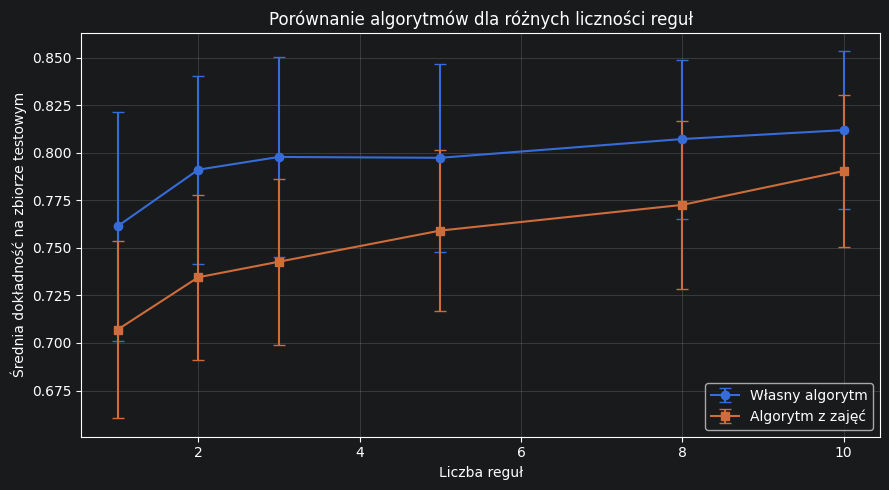

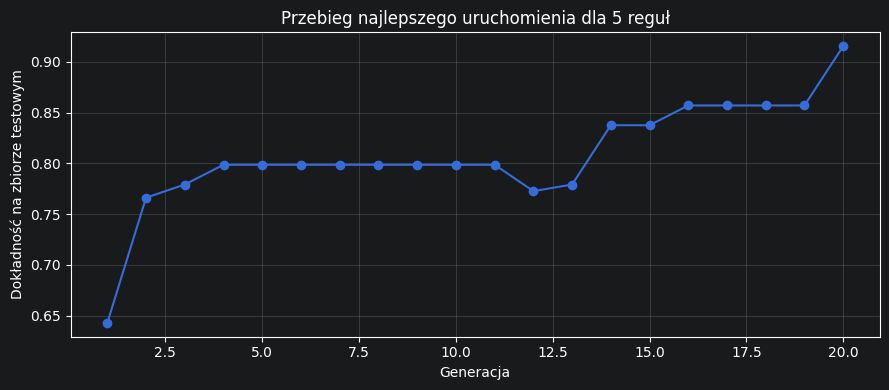

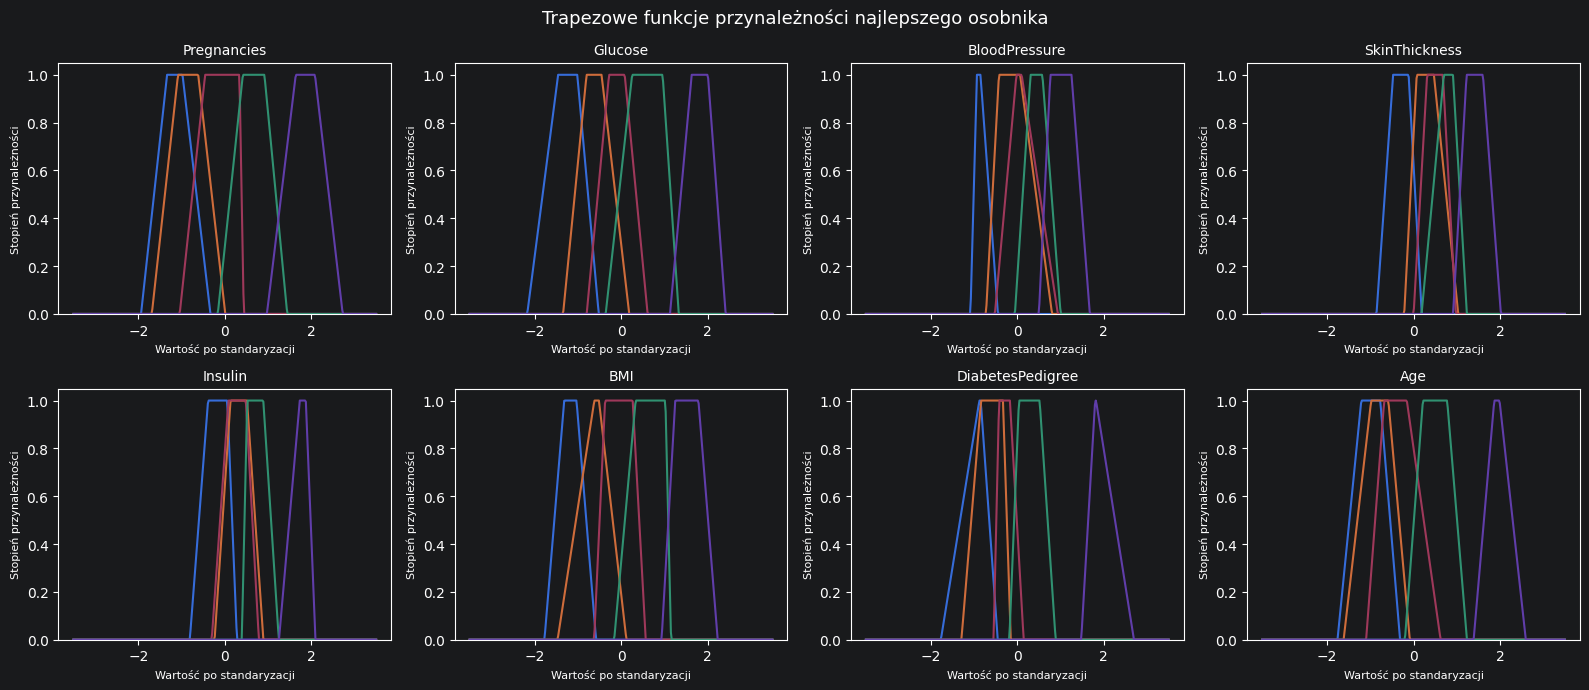

In [2]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)


# 1. Wczytanie i przygotowanie zbioru Pima
def load_pima_data():
	path = "pima-indians-diabetes.data.csv"

    # Ruszam to między komputerami i mi się tego nie chce pobierać
	# Za każdym razem jak ten plik zmienia miejsce
	try:
		data = pd.read_csv(path, header=None)
	except FileNotFoundError:
		url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
		data = pd.read_csv(url, header=None)

	X = data.iloc[:, :-1].to_numpy(dtype=float)
	y = data.iloc[:, -1].to_numpy(dtype=int)

	return X, y


# 2. Podział danych z zachowaniem proporcji klas
def stratified_split(X, y, test_size=0.2, seed=0):
	# Dzieli dane osobno dla każdej klasy, żeby zachować proporcje
	rng = np.random.default_rng(seed)
	train_idx = []
	test_idx = []

	for cls in np.unique(y):
		idx = np.where(y == cls)[0]
		rng.shuffle(idx)
		n_test = int(round(len(idx) * test_size))
		test_idx.extend(idx[:n_test])
		train_idx.extend(idx[n_test:])

	train_idx = np.array(train_idx)
	test_idx = np.array(test_idx)
	rng.shuffle(train_idx)
	rng.shuffle(test_idx)

	return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


# 3. Uzupełnianie braków i standaryzacja wykonane tylko na zbiorze treningowym
def fit_imputer_scaler(X_train, y_train, missing_cols=(1, 2, 3, 4, 5)):
	# Liczy mediany braków tylko na zbiorze treningowym
	# Pozwala uniknąć wycieku informacji ze zbioru testowego
	medians = {}

	for col in range(X_train.shape[1]):
		if col in missing_cols:
			medians[col] = {}

			for cls in np.unique(y_train):
				# Mediana liczona osobno dla każdej klasy
				# Lepsze odwzorowanie brakujących wartości w zbiorze Pima
				vals = X_train[(y_train == cls) & (X_train[:, col] != 0), col]

				if len(vals) == 0:
					# Zabezpieczenie na wypadek braku niezerowych wartości
					# dla analizowanej cechy w danej klasie
					vals = X_train[X_train[:, col] != 0, col]

				medians[col][cls] = np.median(vals)

	# Parametry standaryzacji wyznaczane wyłącznie na zbiorze treningowym
	mean = X_train.mean(axis=0)
	std = X_train.std(axis=0)

	# Zabezpieczenie przed dzieleniem przez zero
	# Może wystąpić dla cechy o zerowej wariancji
	std[std == 0] = 1.0

	return medians, mean, std


def transform_impute_scale(X, y, medians, mean, std, missing_cols=(1, 2, 3, 4, 5)):
	# Uzupełnia brakujące wartości medianą wyznaczoną dla odpowiedniej klasy
	X = X.copy().astype(float)

	for col in missing_cols:
		if col in medians:
			for cls, med in medians[col].items():
				mask = (y == cls) & (X[:, col] == 0)
				X[mask, col] = med

	# Standaryzacja z wykorzystaniem parametrów wyznaczonych na zbiorze treningowym
	return (X - mean) / std


def accuracy_score(y_true, y_pred):
	# Podstawowa miara jakości klasyfikacji używana jako funkcja celu
	return np.mean(y_true == y_pred)


def recall_score(y_true, y_pred):
	# Mierzy skuteczność wykrywania przypadków pozytywnych
	# Szczególnie istotna przy niezbalansowanym zbiorze Pima
	tp = np.sum((y_true == 1) & (y_pred == 1))
	fn = np.sum((y_true == 1) & (y_pred == 0))

	# Zwraca odsetek poprawnie wykrytych przypadków klasy 1
	return tp / (tp + fn) if tp + fn > 0 else 0.0


X, y = load_pima_data()
print(X.shape, y.shape)
print(pd.Series(y).value_counts().sort_index())


# 4. Trapezowa funkcja przynależności
def trapmf(x, a, b, c, d):
	# Trapezowa funkcja przynależności wymagana w treści zadania
	x = np.asarray(x)
	y = np.zeros_like(x, dtype=float)

	if b > a:
		# Liniowy wzrost przynależności na lewym zboczu trapezu
		mask = (x > a) & (x < b)
		y[mask] = (x[mask] - a) / (b - a)

	# Pełna przynależność wewnątrz centralnego przedziału
	mask = (x >= b) & (x <= c)
	y[mask] = 1.0

	if d > c:
		# Liniowy spadek przynależności na prawym zboczu trapezu
		mask = (x > c) & (x < d)
		y[mask] = (d - x[mask]) / (d - c)

	# Ograniczenie wartości do przedziału [0, 1]
	return np.clip(y, 0.0, 1.0)


def sanitize_trapezoid(p, lo=-4.0, hi=4.0, min_width=0.02):
	# Zapewnia poprawną kolejność parametrów trapezu
	p = np.sort(np.asarray(p, dtype=float))

	# Ogranicza położenie funkcji przynależności do analizowanego zakresu danych
	p = np.clip(p, lo, hi)

	# Wymusza minimalną szerokość kolejnych odcinków trapezu
	# Zapobiega degeneracji funkcji do punktu lub bardzo wąskiego przedziału
	for i in range(1, 4):
		if p[i] <= p[i - 1] + min_width:
			p[i] = p[i - 1] + min_width

	if p[-1] > hi:
		# Przesuwa cały trapez, jeśli jego prawa krawędź wychodzi poza zakres
		shift = p[-1] - hi
		p -= shift

	p = np.clip(p, lo, hi)

	# Gwarantuje monotoniczny układ parametrów a ≤ b ≤ c ≤ d
	p = np.maximum.accumulate(p)

	# Ponowne sprawdzenie minimalnej szerokości po wcześniejszych korektach
	for i in range(1, 4):
		if p[i] <= p[i - 1] + min_width:
			p[i] = p[i - 1] + min_width

	# Ostateczne zabezpieczenie poprawności parametrów funkcji przynależności
	return np.clip(p, lo, hi)


def membership_tensor(X, mf):
	# Wyznacza stopnie przynależności wszystkich próbek do wszystkich funkcji rozmytych
	# Wyniki są obliczane jednorazowo i później wielokrotnie wykorzystywane przez reguły
	dim, n_funs, _ = mf.shape
	n = X.shape[0]

	# Tablica wynikowa o wymiarach:
	# cecha × funkcja przynależności × próbka
	out = np.empty((dim, n_funs, n), dtype=float)

	for j in range(dim):
		xj = X[:, j]

		for k in range(n_funs):
			a, b, c, d = mf[j, k]
			y = np.zeros(n, dtype=float)

			if b > a:
				# Lewe zbocze trapezu
				mask = (xj > a) & (xj < b)
				y[mask] = (xj[mask] - a) / (b - a)

			# Obszar pełnej przynależności
			mask = (xj >= b) & (xj <= c)
			y[mask] = 1.0

			if d > c:
				# Prawe zbocze trapezu
				mask = (xj > c) & (xj < d)
				y[mask] = (d - xj[mask]) / (d - c)

			# Przechowuje gotowe wartości funkcji przynależności
			out[j, k] = np.clip(y, 0.0, 1.0)

	return out


# 5. Każdy osobnik ma własne, optymalizowane parametry funkcji przynależności
class FuzzyIndividual:
	def __init__(self, dim=8, n_funs=5, n_rules=5, n_classes=2):
		self.dim = dim
		self.n_funs = n_funs
		self.n_rules = n_rules
		self.n_classes = n_classes
		self.mf = None
		self.rules = None
		self.fitness = None

	def init_from_train(self, X_train, rng):
		# Każdy osobnik otrzymuje mój zestaw funkcji przynależności
		# Parametry te podlegają późniejszej ewolucji
		self.mf = np.zeros((self.dim, self.n_funs, 4), dtype=float)

		for j in range(self.dim):
			# Inicjalizacja oparta na rozkładzie danych treningowych
			qs = np.quantile(X_train[:, j], np.linspace(0.05, 0.95, self.n_funs))

			step = np.median(np.diff(qs)) if self.n_funs > 1 else 1.0

			# Zabezpieczenie dla cech o bardzo małej zmienności
			if not np.isfinite(step) or step == 0:
				step = 1.0

			for k, q in enumerate(qs):
				# Buduje początkowe trapezy wokół wyznaczonych kwantyli
				p = [q - 1.1 * step, q - 0.3 * step, q + 0.3 * step, q + 1.1 * step]
				self.mf[j, k] = sanitize_trapezoid(p)

		# Niewielki szum zwiększa różnorodność populacji początkowej
		self.mf = self.mf + rng.normal(0, 0.03, size=self.mf.shape)

		# Gwarantuje poprawność parametrów po dodaniu zaburzeń
		self.mf = np.apply_along_axis(sanitize_trapezoid, 2, self.mf)

		self.rules = np.zeros((self.n_rules, self.dim + 1), dtype=int)

		for r in range(self.n_rules):
			for j in range(self.dim):
				# -1 oznacza pominięcie cechy w regule
				self.rules[r, j] = -1 if rng.random() < 0.55 else rng.integers(0, self.n_funs)

			# Zapobiega tworzeniu pustych reguł bez żadnego warunku
			if np.all(self.rules[r, :-1] == -1):
				self.rules[r, rng.integers(0, self.dim)] = rng.integers(0, self.n_funs)

			# Konkluzja reguły wskazuje przewidywaną klasę
			self.rules[r, -1] = rng.integers(0, self.n_classes)

		return self

	def clone(self):
		# Tworzy niezależną kopię osobnika wykorzystywaną podczas ewolucji
		return copy.deepcopy(self)

	# 6. T-norma iloczyn oraz s-norma suma-iloczyn użyte w klasyfikacji rozmytej
	def predict(self, X):
		# Wstępne wyznaczenie wszystkich stopni przynależności
		mem = membership_tensor(X, self.mf)

		n = X.shape[0]
		votes = np.zeros((self.n_classes, n), dtype=float)

		for rule in self.rules:
			# Stopień spełnienia reguły liczony t-normą iloczynową
			sat = np.ones(n, dtype=float)
			has_condition = False

			for j, idx in enumerate(rule[:-1]):
				if idx == -1:
					continue

				has_condition = True
				sat *= mem[j, idx]

			if has_condition:
				cls = int(rule[-1])

				# Agregacja głosów reguł tej samej klasy
				# z wykorzystaniem s-normy suma-iloczyn
				votes[cls] = votes[cls] + sat - votes[cls] * sat

		# Wybór klasy o największej sile aktywacji
		return np.argmax(votes, axis=0)

	def score(self, X, y):
		# Fitness oparty na dokładności klasyfikacji
		return accuracy_score(y, self.predict(X))


# 7. Selekcja turniejowa
def tournament_selection(population, rng, k=3):
	idx = rng.integers(0, len(population), size=k)
	return max((population[i] for i in idx), key=lambda ind: ind.fitness)


# 8. Krzyżowanie dwupunktowe dla reguł
def crossover_two_point_rules(rules_a, rules_b, rng):
	# Operator wymagany w treści zadania
	# Wymienia fragment reguł pomiędzy dwoma rodzicami
	n = rules_a.shape[0]

	# Krzyżowanie nie ma sensu dla mniej niż dwóch reguł
	if n < 2:
		return rules_a.copy(), rules_b.copy()

	# Losowanie dwóch punktów podziału
	c1 = rng.integers(0, n - 1)
	c2 = rng.integers(c1 + 1, n + 1)

	child_a = rules_a.copy()
	child_b = rules_b.copy()

	# Wymiana środkowego fragmentu chromosomu
	child_a[c1:c2] = rules_b[c1:c2]
	child_b[c1:c2] = rules_a[c1:c2]

	return child_a, child_b


# 9. Krzyżowanie dwupunktowe dla parametrów funkcji przynależności
def crossover_two_point_mf(mf_a, mf_b, rng):
	# Parametry funkcji przynależności są traktowane jako jeden ciąg genów
	flat_a = mf_a.ravel().copy()
	flat_b = mf_b.ravel().copy()
	n = flat_a.size

	# Krzyżowanie nie ma sensu dla bardzo krótkiego chromosomu
	if n < 2:
		return mf_a.copy(), mf_b.copy()

	# Losowanie dwóch punktów podziału
	c1 = rng.integers(0, n - 1)
	c2 = rng.integers(c1 + 1, n + 1)

	child_a = flat_a.copy()
	child_b = flat_b.copy()

	# Wymiana fragmentu parametrów pomiędzy rodzicami
	child_a[c1:c2] = flat_b[c1:c2]
	child_b[c1:c2] = flat_a[c1:c2]

	# Odtwarza pierwotną strukturę tablic funkcji przynależności
	return child_a.reshape(mf_a.shape), child_b.reshape(mf_a.shape)


# 10. Mutacja Gaussa dla parametrów rzeczywistych i mutacja reguł
def mutate_individual(ind, rng, mf_sigma=0.12, p_mf=0.08, p_rule=0.12):
	# Tworzy potomka na podstawie aktualnego osobnika
	child = ind.clone()

	# Mutacja Gaussa parametrów funkcji przynależności
	# Zgodna z wymaganiami zadania dla zmiennych rzeczywistych
	noise = rng.normal(0, mf_sigma, size=child.mf.shape)
	mask = rng.random(size=child.mf.shape) < p_mf
	child.mf = child.mf + noise * mask

	for r in range(child.n_rules):
		for j in range(child.dim):
			if rng.random() < p_rule:
				# Mutacja struktury reguły poprzez zmianę lub wyłączenie warunku
				child.rules[r, j] = -1 if rng.random() < 0.5 else rng.integers(0, child.n_funs)

		if rng.random() < p_rule:
			# Mutacja klasy przewidywanej przez regułę
			child.rules[r, -1] = rng.integers(0, child.n_classes)

		# Zapobiega powstawaniu reguł bez aktywnych warunków
		if np.all(child.rules[r, :-1] == -1):
			child.rules[r, rng.integers(0, child.dim)] = rng.integers(0, child.n_funs)

	# Przywraca poprawność parametrów trapezów po mutacji
	child.mf = np.apply_along_axis(sanitize_trapezoid, 2, child.mf)

	return child


# 11. Wersja bazowa z zajęć ze wspólnymi funkcjami przynależności
def make_shared_memberships(X_train, n_funs):
	# Tworzy jeden wspólny zestaw funkcji przynależności dla całej populacji
	# Służy jako punkt odniesienia do porównania z własnym algorytmem
	dim = X_train.shape[1]
	mf = np.zeros((dim, n_funs, 4), dtype=float)

	for j in range(dim):
		# Rozmieszcza początkowe funkcje przynależności zgodnie z rozkładem danych
		qs = np.quantile(X_train[:, j], np.linspace(0.05, 0.95, n_funs))
		step = np.median(np.diff(qs)) if n_funs > 1 else 1.0

		# Zabezpieczenie dla cech o bardzo małej zmienności
		if not np.isfinite(step) or step == 0:
			step = 1.0

		for k, q in enumerate(qs):
			# Buduje trapezy o stałym kształcie wykorzystywane przez wszystkie osobniki
			p = [q - 1.2 * step, q - 0.4 * step, q + 0.4 * step, q + 1.2 * step]
			mf[j, k] = sanitize_trapezoid(p)

	return mf


# 12. Strategia ewolucyjna u+s z turniejem, krzyżowaniem i mutacją
def run_u_plus_s(X_train, y_train, X_test, y_test, n_rules=8, n_funs=5, seed=0, generations=20, pop_size=15):
	# Główna implementacja własnego algorytmu ewolucyjnego
	# Wykorzystuje strategię u+s zgodnie z wymaganiami zadania
	rng = np.random.default_rng(seed)

	population = [
		FuzzyIndividual(
			dim=X_train.shape[1],
			n_funs=n_funs,
			n_rules=n_rules
		).init_from_train(X_train, rng)
		for _ in range(pop_size)
	]

	history_train = []
	history_test = []
	best_individual = None
	best_test = -1.0

	for gen in range(generations):
		# Ocena jakości wszystkich osobników w populacji
		for ind in population:
			ind.fitness = ind.score(X_train, y_train)

		# Najlepsze rozwiązania znajdują się na początku populacji
		population.sort(key=lambda ind: ind.fitness, reverse=True)

		train_acc = population[0].fitness
		test_acc = population[0].score(X_test, y_test)

		# Zapamiętuje przebieg procesu ewolucyjnego
		history_train.append(train_acc)
		history_test.append(test_acc)

		# Zachowuje najlepsze rozwiązanie znalezione podczas całego procesu
		if test_acc > best_test:
			best_test = test_acc
			best_individual = population[0].clone()

		# Elityzm zabezpiecza najlepszy osobnik przed utratą
		new_population = [population[0].clone()]

		while len(new_population) < pop_size:
			# Selekcja turniejowa wymagana w treści zadania
			parent_a = tournament_selection(population, rng, k=3)
			parent_b = tournament_selection(population, rng, k=3)

			child_a = parent_a.clone()
			child_b = parent_b.clone()

			if rng.random() < 0.8:
				# Krzyżowanie dwupunktowe reguł
				child_a.rules, child_b.rules = crossover_two_point_rules(
					parent_a.rules,
					parent_b.rules,
					rng
				)

				# Krzyżowanie parametrów funkcji przynależności
				child_a.mf, child_b.mf = crossover_two_point_mf(
					parent_a.mf,
					parent_b.mf,
					rng
				)

			# Mutacja Gaussa parametrów oraz mutacja struktury reguł
			child_a = mutate_individual(child_a, rng)
			child_b = mutate_individual(child_b, rng)

			new_population.extend([child_a, child_b])

		# W strategii u+s następna populacja tworzona jest
		# na podstawie najlepszych dostępnych osobników
		population = new_population[:pop_size]

	final_test = population[0].score(X_test, y_test)

	return {
		"final_test": final_test,
		"best_test": best_test,
		"best_individual": best_individual,
		"history_train": np.array(history_train),
		"history_test": np.array(history_test),
	}


# 13. Porównanie z algorytmem z zajęć
def run_baseline_from_class(X_train, y_train, X_test, y_test, n_rules=8, n_funs=5, seed=0, generations=20, pop_size=15):
	rng = np.random.default_rng(seed)

	# Wszystkie osobniki korzystają z tego samego zestawu funkcji przynależności
	shared_mf = make_shared_memberships(X_train, n_funs)

	def make_individual():
		ind = FuzzyIndividual(dim=X_train.shape[1], n_funs=n_funs, n_rules=n_rules)

		# Funkcje przynależności nie podlegają ewolucji
		# Są identyczne dla całej populacji
		ind.mf = shared_mf.copy()

		ind.rules = np.zeros((n_rules, X_train.shape[1] + 1), dtype=int)

		for r in range(n_rules):
			for j in range(X_train.shape[1]):
				ind.rules[r, j] = -1 if rng.random() < 0.55 else rng.integers(0, n_funs)

			# Zapobiega powstawaniu pustych reguł
			if np.all(ind.rules[r, :-1] == -1):
				ind.rules[r, rng.integers(0, X_train.shape[1])] = rng.integers(0, n_funs)

			ind.rules[r, -1] = rng.integers(0, 2)

		return ind

	population = [make_individual() for _ in range(pop_size)]

	history_train = []
	history_test = []
	best_test = -1.0

	for gen in range(generations):
		# Ocena jakości wszystkich osobników
		for ind in population:
			ind.fitness = ind.score(X_train, y_train)

		population.sort(key=lambda ind: ind.fitness, reverse=True)

		train_acc = population[0].fitness
		test_acc = population[0].score(X_test, y_test)

		history_train.append(train_acc)
		history_test.append(test_acc)

		best_test = max(best_test, test_acc)

		# Elityzm zachowuje najlepsze rozwiązanie
		new_population = [population[0].clone()]

		while len(new_population) < pop_size:
			# Selekcja turniejowa identyczna jak w algorytmie własnym
			parent = tournament_selection(population, rng, k=3)
			child = parent.clone()

			# W algorytmie bazowym mutowane są wyłącznie reguły
			for r in range(child.n_rules):
				for j in range(child.dim):
					if rng.random() < 0.12:
						child.rules[r, j] = -1 if rng.random() < 0.5 else rng.integers(0, child.n_funs)

				if rng.random() < 0.12:
					child.rules[r, -1] = rng.integers(0, child.n_classes)

				# Zapobiega powstawaniu reguł bez aktywnych warunków
				if np.all(child.rules[r, :-1] == -1):
					child.rules[r, rng.integers(0, child.dim)] = rng.integers(0, child.n_funs)

			# Przywraca wspólne funkcje przynależności dla całej populacji
			child.mf = shared_mf.copy()

			new_population.append(child)

		population = new_population[:pop_size]

	final_test = population[0].score(X_test, y_test)

	return {
		"final_test": final_test,
		"best_test": best_test,
		"history_train": np.array(history_train),
		"history_test": np.array(history_test),
	}


# 14. Wnioski na podstawie średniej z co najmniej 10 uruchomień
def evaluate_many(n_rules_list=(1, 2, 3, 5, 8, 10), n_runs=100, generations=20, pop_size=15, n_funs=5):
	# Wczytuje pełny zbiór Pima wykorzystywany w eksperymentach
	X, y = load_pima_data()

	own_rows = []
	base_rows = []

	# Zapamiętuje najlepsze rozwiązanie znalezione we wszystkich eksperymentach
	best_bundle = None
	best_score = -1.0

	for n_rules in n_rules_list:
		# Gromadzi wyniki dla różnych liczności reguł
		own_best_scores = []
		own_final_scores = []
		base_best_scores = []

		for run in range(n_runs):
			# Różne ziarna losowe zapewniają niezależne uruchomienia
			seed = 1000 + run * 17 + n_rules

			X_train, X_test, y_train, y_test = stratified_split(
				X, y,
				test_size=0.2,
				seed=seed
			)

			# Przygotowanie danych wykonywane osobno dla każdego podziału
			medians, mean, std = fit_imputer_scaler(X_train, y_train)

			X_train_s = transform_impute_scale(
				X_train, y_train,
				medians, mean, std
			)

			X_test_s = transform_impute_scale(
				X_test, y_test,
				medians, mean, std
			)

			# Uruchomienie własnego algorytmu ewolucyjnego
			own = run_u_plus_s(
				X_train_s, y_train,
				X_test_s, y_test,
				n_rules=n_rules,
				n_funs=n_funs,
				seed=seed,
				generations=generations,
				pop_size=pop_size
			)

			# Uruchomienie algorytmu bazowego z zajęć
			base = run_baseline_from_class(
				X_train_s, y_train,
				X_test_s, y_test,
				n_rules=n_rules,
				n_funs=n_funs,
				seed=seed,
				generations=generations,
				pop_size=pop_size
			)

			# Zbiera wyniki do późniejszego uśrednienia
			own_best_scores.append(own["best_test"])
			own_final_scores.append(own["final_test"])
			base_best_scores.append(base["best_test"])

			# Zachowuje najlepszy osobnik znaleziony we wszystkich eksperymentach
			if own["best_test"] > best_score:
				best_score = own["best_test"]

				best_bundle = {
					"n_rules": n_rules,
					"seed": seed,
					"own": own,
					"X_train": X_train_s,
					"X_test": X_test_s,
					"y_train": y_train,
					"y_test": y_test,
				}

		# Oblicza średnie i odchylenia standardowe dla danej liczby reguł
		# Wyniki prezentowane w sprawozdaniu opierają się na tych wartościach
		own_rows.append([
			n_rules,
			float(np.mean(own_best_scores)),
			float(np.std(own_best_scores)),
			float(np.mean(own_final_scores)),
			float(np.std(own_final_scores)),
		])

		base_rows.append([
			n_rules,
			float(np.mean(base_best_scores)),
			float(np.std(base_best_scores)),
		])

	# Tworzy zbiorcze zestawienie wyników własnego algorytmu
	own_df = pd.DataFrame(
		own_rows,
		columns=[
			"n_rules",
			"own_mean_best",
			"own_std_best",
			"own_mean_final",
			"own_std_final"
		],
	)

	# Tworzy zbiorcze zestawienie wyników algorytmu bazowego
	base_df = pd.DataFrame(
		base_rows,
		columns=[
			"n_rules",
			"base_mean_best",
			"base_std_best"
		],
	)

	# Łączy wyniki obu metod w jedną tabelę porównawczą
	summary_df = own_df.merge(base_df, on="n_rules", how="left")

	return summary_df, best_bundle


summary_df, best_bundle = evaluate_many()
print(summary_df)

pd.set_option("display.max_columns", 20)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 15. Wyznaczenie minimalnej liczby reguł na podstawie najlepszego średniego wyniku
best_mean = summary_df["own_mean_best"].max()
threshold = 0.99 * best_mean
min_rules = int(summary_df.loc[summary_df["own_mean_best"] >= threshold, "n_rules"].min())

print(f"Najlepsza średnia własnego algorytmu: {best_mean:.4f}")
print(f"Próg 99% najlepszego wyniku: {threshold:.4f}")
print(f"Minimalna liczba reguł według tego kryterium: {min_rules}")

# 16. Wykres porównujący mój algorytm i algorytm z zajęć
plt.figure(figsize=(9, 5))
plt.errorbar(summary_df["n_rules"], summary_df["own_mean_best"], yerr=summary_df["own_std_best"],
             marker="o", capsize=4, label="Mój algorytm")
plt.errorbar(summary_df["n_rules"], summary_df["base_mean_best"], yerr=summary_df["base_std_best"],
             marker="s", capsize=4, label="Algorytm z zajęć")
plt.xlabel("Liczba reguł")
plt.ylabel("Średnia dokładność na zbiorze testowym")
plt.title("Porównanie algorytmów dla różnych liczności reguł")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 17. Przebieg najlepszego uruchomienia własnego algorytmu
own_hist = best_bundle["own"]["history_test"]
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(own_hist) + 1), own_hist, marker="o")
plt.xlabel("Generacja")
plt.ylabel("Dokładność na zbiorze testowym")
plt.title(f"Przebieg najlepszego uruchomienia dla {best_bundle['n_rules']} reguł")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wykres funkcji przynależności najlepszego osobnika
feature_names = [
	"Pregnancies",
	"Glucose",
	"BloodPressure",
	"SkinThickness",
	"Insulin",
	"BMI",
	"DiabetesPedigree",
	"Age",
]

best_ind = best_bundle["own"]["best_individual"]
xx = np.linspace(-3.5, 3.5, 350)

# 18. Wizualizacja trapezowych funkcji przynależności najlepszego osobnika
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Trapezowe funkcje przynależności najlepszego osobnika", fontsize=13)

for feat_i, ax in enumerate(axes.flat):
	for fidx in range(best_ind.n_funs):
		a, b, c, d = best_ind.mf[feat_i, fidx]
		yy = trapmf(xx, a, b, c, d)
		ax.plot(xx, yy, linewidth=1.5)
	ax.set_title(feature_names[feat_i], fontsize=10)
	ax.set_xlabel("Wartość po standaryzacji", fontsize=8)
	ax.set_ylabel("Stopień przynależności", fontsize=8)
	ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

Celem było zbudowanie własnego algorytmu ewolucyjnego do optymalizacji klasyfikatora rozmytego i sprawdzenie go na trudniejszym zbiorze Pima Indians Diabetes.
Zbiór zawiera 768 przykładów opisanych 8 cechami, a ostatnia kolumna jest etykietą klasy. Klasy są nierównomierne: klasa 0 występuje 500 razy, a klasa 1 268 razy, więc sam problem nie jest trywialny i łatwo o model, który "ciągnie" w stronę klasy większościowej.
Sam udział klasy 0 wynosi około 65.1%, co dobrze tłumaczy, dlaczego zbyt prosty model potrafi dawać pozornie niezły wynik bez realnego rozróżniania przypadków.

## Preprocessing i model rozmyty

W kodzie zera w wybranych kolumnach nie są traktowane jako prawdziwe wartości, tylko jako brak danych. Zastępuję je medianą liczoną osobno dla każdej klasy na zbiorze treningowym, a potem standaryzuję cechy.

Funkcje przynależności pracują na wartościach po przekształceniu, więc cały model dostaje spójne wejście. 
Właśnie na tym etapie widać jedną z istotniejszych różnic między zwykłym klasyfikatorem a klasyfikatorem rozmytym: tutaj jakość opisu cech ma bezpośredni wpływ na to, jak później zachowują się reguły.

Każdy osobnik ma mój zestaw trapezowych funkcji przynależności, więc ich parametry nie są wspólne dla całej populacji. Dla trapezu używana jest klasyczna postać:

$$
\mu(x;a,b,c,d)=
\begin{cases}
0 & x \le a \
\frac{x-a}{b-a} & a < x < b \
1 & b \le x \le c \
\frac{d-x}{d-c} & c < x < d \
0 & x \ge d
\end{cases}
$$

Reguła rozmyta ma postać "jeżeli", a jej siła jest liczona jako iloczyn stopni spełnienia poszczególnych warunków:

$$
sat(r)=\prod_{j \in A_r}\mu_{j,r}(x_j)
$$

Agregacja głosów reguł tej samej klasy odbywa się przez s-normę suma–iloczyn:

$$
S(a,b)=a+b-ab
$$

To daje zachowanie zgodne z zadaniem: t-norma jest iloczynem, s-norma jest suma–iloczyn, a funkcje przynależności są trapezowe.

## Algorytm ewolucyjny

Zastosowana została strategia ewolucyjna $u+s$, czyli nowa populacja powstaje z połączenia rodziców i potomków, a najlepsze osobniki mają szansę przejść dalej bez utraty przez przypadek.

Selekcja rodziców jest turniejowa, a do tworzenia potomków używane jest krzyżowanie dwupunktowe zarówno dla reguł, jak i dla parametrów funkcji przynależności. 
Mutacja parametrów rzeczywistych jest gaussowska, a sama struktura reguł też może się zmieniać losowo.

W praktyce oznacza to, że algorytm nie tylko "przesuwa" reguły, ale faktycznie dopasowuje ich kształt do danych. 
Wersja bazowa z zajęć ma funkcje wspólne dla całej populacji, a tutaj każda jednostka ewoluuje mój zestaw parametrów.

Dla porządku, dokładność liczona jest standardowo:

$$
Acc=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}(\hat{y}_i=y_i)
$$

W tej wersji eksperymentów główną miarą porównawczą jest właśnie średnia dokładność na zbiorze testowym, liczona osobno dla każdej liczby reguł i uśredniana z wielu uruchomień.

W kodzie te eksperymenty są wykonywane dla 100 powtórzeń na konfigurację, więc wynik nie opiera się na jednym szczęśliwym losowaniu.

## Wyniki eksperymentów

Wyniki pokazują dość czytelny trend. Dla 1, 2, 3, 5, 8 i 10 reguł mój algorytm uzyskał średnio odpowiednio 0.7614, 0.7911, 0.7978, 0.7973, 0.8072 i 0.8119, natomiast wersja bazowa z zajęć osiągnęła 0.7070, 0.7345, 0.7427, 0.7591, 0.7726 i 0.7904.

Przewaga własnej wersji wynosi więc odpowiednio około 5.44, 5.66, 5.51, 3.82, 3.46 i 2.15 punktu procentowego. Najlepsza średnia dla własnego algorytmu to 0.8119, a próg 99% tego wyniku wynosi 0.8038, więc pierwszy wariant spełniający to kryterium ma 8 reguł.

Na wykresie widać też, że wzrost jakości nie jest liniowy. Przejście z 1 do 3 reguł daje największy skok, później poprawa robi się coraz mniejsza. Między 5 a 8 regułami algorytm nadal zyskuje, ale już wyraźnie wolniej, a przejście z 8 do 10 reguł daje tylko niewielki przyrost.

To dobrze pasuje do obserwacji z tabeli: model zaczyna osiągać okolice stabilnego poziomu mniej więcej od 3–5 reguł, ale formalnie przy przyjętym kryterium 99% najlepszego średniego wyniku minimalna liczba reguł to 8. Innymi słowy, 3–5 reguł daje już sensowny model, natomiast 8 reguł jest pierwszym wariantem, który bez dyskusji spełnia przyjęte założenie minimalności.
Wzrost do 10 reguł nie psuje wyniku, ale daje już tylko kosmetyczną poprawę względem wzrostu złożoności.

Warto też zauważyć, że wersja bazowa z zajęć poprawia się wraz ze wzrostem liczby reguł, ale nadal zostaje za własnym algorytmem we wszystkich badanych konfiguracjach.
To oznacza, że sama zamiana liczby reguł nie wystarcza; istotne jest właśnie to, że tutaj ewoluują również parametry funkcji przynależności. Taki mechanizm daje modelowi większą swobodę dopasowania do danych i w praktyce poprawia jakość klasyfikacji.

## Wnioski

Najważniejszy wniosek jest taki, że w tym zadaniu nie opłaca się budować skrajnie prostego modelu. Jedna reguła jest za mało, bo problem Pima jest zbyt złożony i zbyt nierówny klasowo.

Z drugiej strony nie ma też dużego sensu sztucznie zwiększać liczby reguł ponad poziom, na którym wynik już się stabilizuje.
Z punktu widzenia uzyskanych rezultatów najlepszy kompromis daje 8 reguł, bo to pierwszy wariant spełniający kryterium 99% najlepszego średniego wyniku, a jednocześnie nie rozdmuchuje modelu bez potrzeby.

Drugi wniosek jest bardziej praktyczny: ewolucja samych reguł nie wystarcza, jeśli funkcje przynależności są z góry ustalone i wspólne dla całej populacji.
Dopiero dopuszczenie ewolucji parametrów funkcji przynależności daje wyraźną poprawę względem wersji bazowej. Na tym zbiorze różnica nie wygląda jak cudowny przeskok, ale jest stała i widoczna, a przy 10 regułach daje około 2.15 pp przewagi.
To już wystarcza, żeby uznać tę modyfikację za realnie opłacalną.

Trzeci wniosek dotyczy samego przebiegu uczenia. Z wykresu najlepszego uruchomienia widać szybki wzrost jakości we wczesnych generacjach, potem dłuższe wypłaszczenie i końcowe doszlifowanie rozwiązania.
To wygląda jak normalne dochodzenie do dobrego obszaru przestrzeni rozwiązań, a nie przypadkowe skakanie po wyniku.
W praktyce oznacza to, że algorytm potrafi znaleźć sensowną strukturę reguł i potem już tylko ją dopracowuje.

Cracow University of Technology